# Skenario 1 — Baseline (3D-CNN Murni, Tanpa Atensi)

Notebook ini melatih **AttentiveSkel-3D v2 versi Baseline** sebagai *lower-bound* eksperimen.
Seluruh modul atensi dinonaktifkan — arsitektur berjalan sebagai 3D-CNN murni.

| Modul | Status |
|---|---|
| Biomechanical Spatial Prior (BSP) | ❌ NONAKTIF |
| Learned Spatial Attention | ❌ NONAKTIF |
| Temporal Attention | ❌ NONAKTIF |

**Tujuan:** Mengukur akurasi dasar tanpa kontribusi mekanisme atensi apapun.
Hasil ini akan dijadikan acuan perbandingan terhadap Skenario 2 (Full Model) dan Skenario 3 (Ablasi).

**Prasyarat:** Jalankan `python src/data/v2/build_manifest.py` terlebih dahulu.

In [1]:
import sys
from pathlib import Path

# Tambahkan root proyek ke sys.path agar modul src dapat diimport
PROJECT_ROOT = Path("..").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.data.v2.dataset import create_dataloaders_v2
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame, count_parameters
from src.models.v2.train import train_model_v2, evaluate_one_epoch_v2

print(f"[INFO] PyTorch : {torch.__version__}")
print(f"[INFO] CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU     : {torch.cuda.get_device_name(0)}")

[INFO] PyTorch : 2.5.1
[INFO] CUDA    : True
[INFO] GPU     : NVIDIA GeForce RTX 3060 Ti


In [2]:
# ============================================================
# Muat DataLoader dari manifest_v2.csv
# ============================================================
MANIFEST_V2 = PROJECT_ROOT / "data" / "processed" / "manifest_v2.csv"

train_loader, val_loader, test_loader = create_dataloaders_v2(
    csv_file    = MANIFEST_V2,
    batch_size  = 16,       # Ukuran batch standar
    train_ratio = 0.70,
    val_ratio   = 0.15,
    num_workers = 0,        # 0 di Windows untuk menghindari masalah multiprocessing
    random_seed = 42,       # Seed sama dengan skenario lain agar split data identik
)

# Verifikasi shape satu batch
sample_input, sample_labels = next(iter(train_loader))
print(f"\n[VERIFIKASI] Shape input  : {sample_input.shape}   # (B, 64, 33, 3)")
print(f"[VERIFIKASI] Shape labels : {sample_labels.shape}  # (B, 64)")

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch

[VERIFIKASI] Shape input  : torch.Size([16, 64, 33, 3])   # (B, 64, 33, 3)
[VERIFIKASI] Shape labels : torch.Size([16, 64])  # (B, 64)


In [3]:
# ============================================================
# Inisialisasi Model — SKENARIO 1: BASELINE (semua atensi dinonaktifkan)
# ============================================================
model = AttentiveSkel3DPerFrame(
    num_classes            = 2,     # 0 = Benar, 1 = Salah
    use_spatial_prior      = False, # BSP NONAKTIF — tidak ada bobot per sendi
    use_learned_spatial    = False, # Learned Spatial Attention NONAKTIF
    use_temporal_attention = False, # Temporal Attention NONAKTIF
)

print(f"[INFO] Skenario  : 1 — Baseline (3D-CNN Murni, Tanpa Atensi)")
print(f"[INFO] Parameter : {count_parameters(model):,}")

# CrossEntropyLoss — reshape (B,64,2)→(B*64,2) dilakukan di train.py
criterion = nn.CrossEntropyLoss()

# Adam lr=1e-3 — konfigurasi optimizer identik dengan skenario lain untuk keadilan uji
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Verifikasi output shape model
with torch.no_grad():
    dummy_out = model(sample_input)
print(f"[VERIFIKASI] Output shape : {dummy_out.shape}  # Wajib (B, 64, 2)")

[INFO] Skenario  : 1 — Baseline (3D-CNN Murni, Tanpa Atensi)
[INFO] Parameter : 101,858
[VERIFIKASI] Output shape : torch.Size([16, 64, 2])  # Wajib (B, 64, 2)


In [4]:
# ============================================================
# Jalankan Training — train_model_v2 otomatis menggunakan CUDA
# ============================================================
SAVE_DIR = PROJECT_ROOT / "models" / "saved_models" / "v2"

history = train_model_v2(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    optimizer     = optimizer,
    num_epochs    = 100,
    save_dir      = SAVE_DIR,
    save_filename = "best_model_baseline.pth",  # Checkpoint Skenario 1
    verbose       = True,
)

[CUDA] GPU terdeteksi: NVIDIA GeForce RTX 3060 Ti

  AttentiveSkel-3D v2 — Per-Frame Training
  Device    : cuda
  Epochs    : 100
  Save path : models\saved_models\v2\best_model_baseline.pth
Epoch [  1/100] ✓ | Train Loss: 0.6109 | Train Acc:  63.50% | Val Loss: 0.5638 | Val Acc:  68.24% | Waktu: 0.7s
Epoch [  2/100] ✓ | Train Loss: 0.5399 | Train Acc:  70.41% | Val Loss: 0.4933 | Val Acc:  77.50% | Waktu: 0.4s
Epoch [  3/100] ✓ | Train Loss: 0.4914 | Train Acc:  74.45% | Val Loss: 0.4440 | Val Acc:  79.15% | Waktu: 0.4s
Epoch [  4/100]   | Train Loss: 0.4549 | Train Acc:  77.49% | Val Loss: 0.4923 | Val Acc:  76.18% | Waktu: 0.4s
Epoch [  5/100] ✓ | Train Loss: 0.4286 | Train Acc:  80.57% | Val Loss: 0.4176 | Val Acc:  81.06% | Waktu: 0.4s
Epoch [  6/100] ✓ | Train Loss: 0.4006 | Train Acc:  81.17% | Val Loss: 0.3900 | Val Acc:  83.60% | Waktu: 0.4s
Epoch [  7/100] ✓ | Train Loss: 0.3730 | Train Acc:  83.43% | Val Loss: 0.3621 | Val Acc:  83.84% | Waktu: 0.4s
Epoch [  8/100]   | Trai

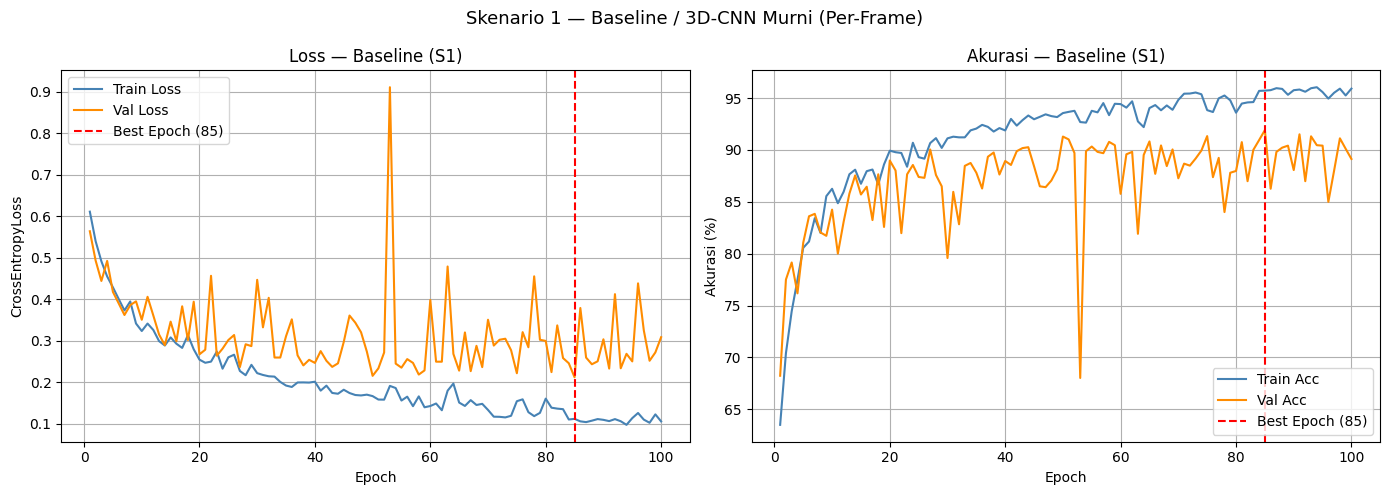

[DONE] Best Epoch   : 85
[DONE] Best Val Loss: 0.2120
[DONE] Best Val Acc : 91.91%


In [5]:
# ============================================================
# Visualisasi Kurva Training
# ============================================================
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="darkorange")
axes[0].axvline(x=history["best_epoch"], color="red", linestyle="--",
                label=f"Best Epoch ({history['best_epoch']})")
axes[0].set_title("Loss — Baseline (S1)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropyLoss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", color="steelblue")
axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   color="darkorange")
axes[1].axvline(x=history["best_epoch"], color="red", linestyle="--",
                label=f"Best Epoch ({history['best_epoch']})")
axes[1].set_title("Akurasi — Baseline (S1)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Akurasi (%)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Skenario 1 — Baseline / 3D-CNN Murni (Per-Frame)", fontsize=13)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / "curve_s1_baseline.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"[DONE] Best Epoch   : {history['best_epoch']}")
print(f"[DONE] Best Val Loss: {history['best_val_loss']:.4f}")
print(f"[DONE] Best Val Acc : {history['val_acc'][history['best_epoch']-1]*100:.2f}%")

In [6]:
# ============================================================
# Evaluasi pada Test Set
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

test_loss, test_acc = evaluate_one_epoch_v2(
    model=model, loader=test_loader, criterion=criterion, device=device
)

print(f"[TEST SET — Skenario 1: Baseline]")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc*100:.2f}%  (per prediksi frame)")

[TEST SET — Skenario 1: Baseline]
  Test Loss     : 0.2701
  Test Accuracy : 90.94%  (per prediksi frame)
